In [1]:
from snowflake.snowpark.context import get_active_session
from snowflake.snowpark.functions import col, avg, count, when, sum
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from snowflake.snowpark import Session
from credentials import params
session = Session.builder.configs(params).create()

df_snowpark = session.table("HOUSING_PRICE_PROJECT.STAGING_LAYER.RAW_DATA")
df = session.sql("SELECT * FROM HOUSING_PRICE_PROJECT.STAGING_LAYER.RAW_DATA").to_pandas()

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 35000 non-null  str    
 1   city                        35000 non-null  str    
 2   locality                    35000 non-null  str    
 3   locality_tier               35000 non-null  str    
 4   property_type               35000 non-null  str    
 5   bhk                         35000 non-null  int8   
 6   bathrooms                   35000 non-null  int8   
 7   balconies                   35000 non-null  int8   
 8   built_up_area               35000 non-null  int16  
 9   carpet_area                 35000 non-null  int16  
 10  floor_number                35000 non-null  int8   
 11  total_floors                35000 non-null  int8   
 12  floor_category              35000 non-null  str    
 13  facing                      35000 non-null

In [3]:
df.describe()

,bhk,bathrooms,balconies,built_up_area,carpet_area,floor_number,total_floors,property_age,parking_spaces,security_score,gym_available,swimming_pool,power_backup,lift_available,maintenance_fee_monthly,distance_to_city_center_km,distance_to_metro_km,nearby_schools,nearby_hospitals,price_in_lakhs
count,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.00000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000
mean,3.151829,3.365343,1.681971,1573.101686,1321.418886,9.33900,14.443086,6.504486,1.919514,5.999220,0.414286,0.299029,0.684657,0.840686,3981.710486,11.541657,2.509520,3.120657,1.906086,166.772213
std,1.214986,1.329136,1.232055,669.493721,563.581272,8.70655,8.817221,6.880724,1.451722,1.601971,0.492605,0.457839,0.464659,0.365974,1637.896999,5.452530,2.477522,1.898308,1.467227,104.714704
min,1.000000,1.000000,0.000000,300.000000,240.000000,0.00000,1.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,500.000000,4.000000,0.100000,0.000000,0.000000,10.000000
25%,2.000000,2.000000,1.000000,1046.750000,878.000000,3.00000,8.000000,2.000000,1.000000,4.900000,0.000000,0.000000,0.000000,1.000000,2682.000000,6.800000,0.700000,2.000000,1.000000,86.127500
50%,3.000000,3.000000,2.000000,1587.000000,1330.000000,7.00000,12.000000,4.000000,2.000000,5.900000,0.000000,0.000000,1.000000,1.000000,3667.000000,11.000000,1.800000,3.000000,2.000000,148.000000
75%,4.000000,4.000000,3.000000,2131.000000,1784.000000,14.00000,18.000000,9.000000,3.000000,7.100000,1.000000,1.000000,1.000000,1.000000,5180.000000,14.300000,3.500000,4.000000,3.000000,226.790000
max,5.000000,6.000000,4.000000,3056.000000,2666.000000,39.00000,45.000000,40.000000,5.000000,10.000000,1.000000,1.000000,1.000000,1.000000,8859.000000,45.000000,15.000000,10.000000,8.000000,737.590000


# Outliers

In [4]:
for i in df.select_dtypes(include=['number']).columns:
    print(f"['{i}', {df[i].min()}, {df[i].max()} ]")

['bhk', 1, 5 ]
['bathrooms', 1, 6 ]
['balconies', 0, 4 ]
['built_up_area', 300, 3056 ]
['carpet_area', 240, 2666 ]
['floor_number', 0, 39 ]
['total_floors', 1, 45 ]
['property_age', 0, 40 ]
['parking_spaces', 0, 5 ]
['security_score', 0.1, 10.0 ]
['gym_available', 0, 1 ]
['swimming_pool', 0, 1 ]
['power_backup', 0, 1 ]
['lift_available', 0, 1 ]
['maintenance_fee_monthly', 500, 8859 ]
['distance_to_city_center_km', 4.0, 45.0 ]
['distance_to_metro_km', 0.1, 15.0 ]
['nearby_schools', 0, 10 ]
['nearby_hospitals', 0, 8 ]
['price_in_lakhs', 10.0, 737.59 ]


In [5]:
col_MinMax_list = [['bhk', 1, 5 ],
['bathrooms', 1, 6 ],
['balconies', 0, 4 ],
['built_up_area', 300, 8000 ],
['carpet_area', 240, 7040 ],
['floor_number', 0, 39 ],
['total_floors', 1, 45 ],  
['property_age', 0, 40 ],  
['parking_spaces', 0, 5 ],
['security_score', 0.0, 10.0 ],
['gym_available', 0, 1 ],
['swimming_pool', 0, 1 ],
['power_backup', 0, 1 ],
['lift_available', 0, 1 ],
['maintenance_fee_monthly', 500, 25000 ],
['distance_to_city_center_km', 0.5, 45.0 ],
['distance_to_metro_km', 0.1, 15.0 ],
['nearby_schools', 0, 10 ],
['nearby_hospitals', 0, 8 ],
['price_in_lakhs', 10.0, 1000.0 ]]

In [6]:
col_MinMax = pd.DataFrame(col_MinMax_list, columns=["col","min_poss","max_poss"])
col_MinMax

,col,min_poss,max_poss
0,bhk,1.0,5.0
1,bathrooms,1.0,6.0
2,balconies,0.0,4.0
3,built_up_area,300.0,8000.0
4,carpet_area,240.0,7040.0
5,floor_number,0.0,39.0
6,total_floors,1.0,45.0
7,property_age,0.0,40.0
8,parking_spaces,0.0,5.0
9,security_score,0.0,10.0


In [7]:
col_MinMax['min_act'] = pd.Series(np.zeros((1,20))[0])
col_MinMax['max_act'] = pd.Series(np.zeros((1,20))[0])
col_MinMax['Q1'] = pd.Series(np.zeros((1,20))[0])
col_MinMax['Q3'] = pd.Series(np.zeros((1,20))[0])
col_MinMax['lower_b'] = pd.Series(np.zeros((1,20))[0])
col_MinMax['upper_b'] = pd.Series(np.zeros((1,20))[0])

In [8]:
for i in col_MinMax.col:
    col_MinMax.loc[col_MinMax.col == i, 'min_act'] = df[i].min()
    col_MinMax.loc[col_MinMax.col == i, 'max_act'] = df[i].max()
    
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    
    col_MinMax.loc[col_MinMax.col == i, 'Q1'] = Q1
    col_MinMax.loc[col_MinMax.col == i, 'Q3'] = Q3
    
    IQR = Q3 - Q1
    
    col_MinMax.loc[col_MinMax.col == i, 'lower_b'] = Q1 - 1.5 * IQR
    col_MinMax.loc[col_MinMax.col == i, 'upper_b'] = Q3 + 1.5 * IQR    

In [9]:
print("col\tmin\tmax\tQ1\tQ3")
for i in col_MinMax.col:
    print(i, end="\t")
    print(df[i].min(), end="\t")
    print(df[i].max(), end="\t")
    print(df[i].quantile(0.25), end="\t")
    print(df[i].quantile(0.75))

col	min	max	Q1	Q3
bhk	1	5	2.0	4.0
bathrooms	1	6	2.0	4.0
balconies	0	4	1.0	3.0
built_up_area	300	3056	1046.75	2131.0
carpet_area	240	2666	878.0	1784.0
floor_number	0	39	3.0	14.0
total_floors	1	45	8.0	18.0
property_age	0	40	2.0	9.0
parking_spaces	0	5	1.0	3.0
security_score	0.1	10.0	4.9	7.1
gym_available	0	1	0.0	1.0
swimming_pool	0	1	0.0	1.0
power_backup	0	1	0.0	1.0
lift_available	0	1	1.0	1.0
maintenance_fee_monthly	500	8859	2682.0	5180.0
distance_to_city_center_km	4.0	45.0	6.8	14.3
distance_to_metro_km	0.1	15.0	0.7	3.5
nearby_schools	0	10	2.0	4.0
nearby_hospitals	0	8	1.0	3.0
price_in_lakhs	10.0	737.59	86.1275	226.79


In [10]:
df['carpet_area'].quantile(0.25)

np.float64(878.0)

In [11]:
col_MinMax

,col,min_poss,max_poss,min_act,max_act,Q1,Q3,lower_b,upper_b
0,bhk,1.0,5.0,1.0,5.00,2.0000,4.00,-1.00000,7.00000
1,bathrooms,1.0,6.0,1.0,6.00,2.0000,4.00,-1.00000,7.00000
2,balconies,0.0,4.0,0.0,4.00,1.0000,3.00,-2.00000,6.00000
3,built_up_area,300.0,8000.0,300.0,3056.00,1046.7500,2131.00,-579.62500,3757.37500
4,carpet_area,240.0,7040.0,240.0,2666.00,878.0000,1784.00,-481.00000,3143.00000
5,floor_number,0.0,39.0,0.0,39.00,3.0000,14.00,-13.50000,30.50000
6,total_floors,1.0,45.0,1.0,45.00,8.0000,18.00,-7.00000,33.00000
7,property_age,0.0,40.0,0.0,40.00,2.0000,9.00,-8.50000,19.50000
8,parking_spaces,0.0,5.0,0.0,5.00,1.0000,3.00,-2.00000,6.00000
9,security_score,0.0,10.0,0.1,10.00,4.9000,7.10,1.60000,10.40000


In [12]:
col_MinMax.max_act - col_MinMax.upper_b > 0

0     False
1     False
2     False
3     False
4     False
5      True
6      True
7      True
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15     True
16     True
17     True
18     True
19     True
dtype: bool

# Correlation Matrix

In [13]:
df["floor_ratio"] = df.floor_number / df.total_floors

In [14]:
numerical_data = df.select_dtypes(include=['number'])
corr_matr = numerical_data.corr(method='pearson')

In [15]:
a=[[1, 0, 1, 0],
   [0, 1, 0, 0],
   [-1, 0, 1, 0],
   [0, 0, 0, 1]
  ]
b=pd.DataFrame(a, columns=["a", "b", "c", "d"], index=["a", "b", "c", "d"])

c = abs(b) > 0.5

selezione = []
for i in c.columns:
    if c[i].sum() > 1:
        selezione.append(i)

c[selezione].loc[selezione]

,a,c
a,True,True
c,True,True


<Axes: >

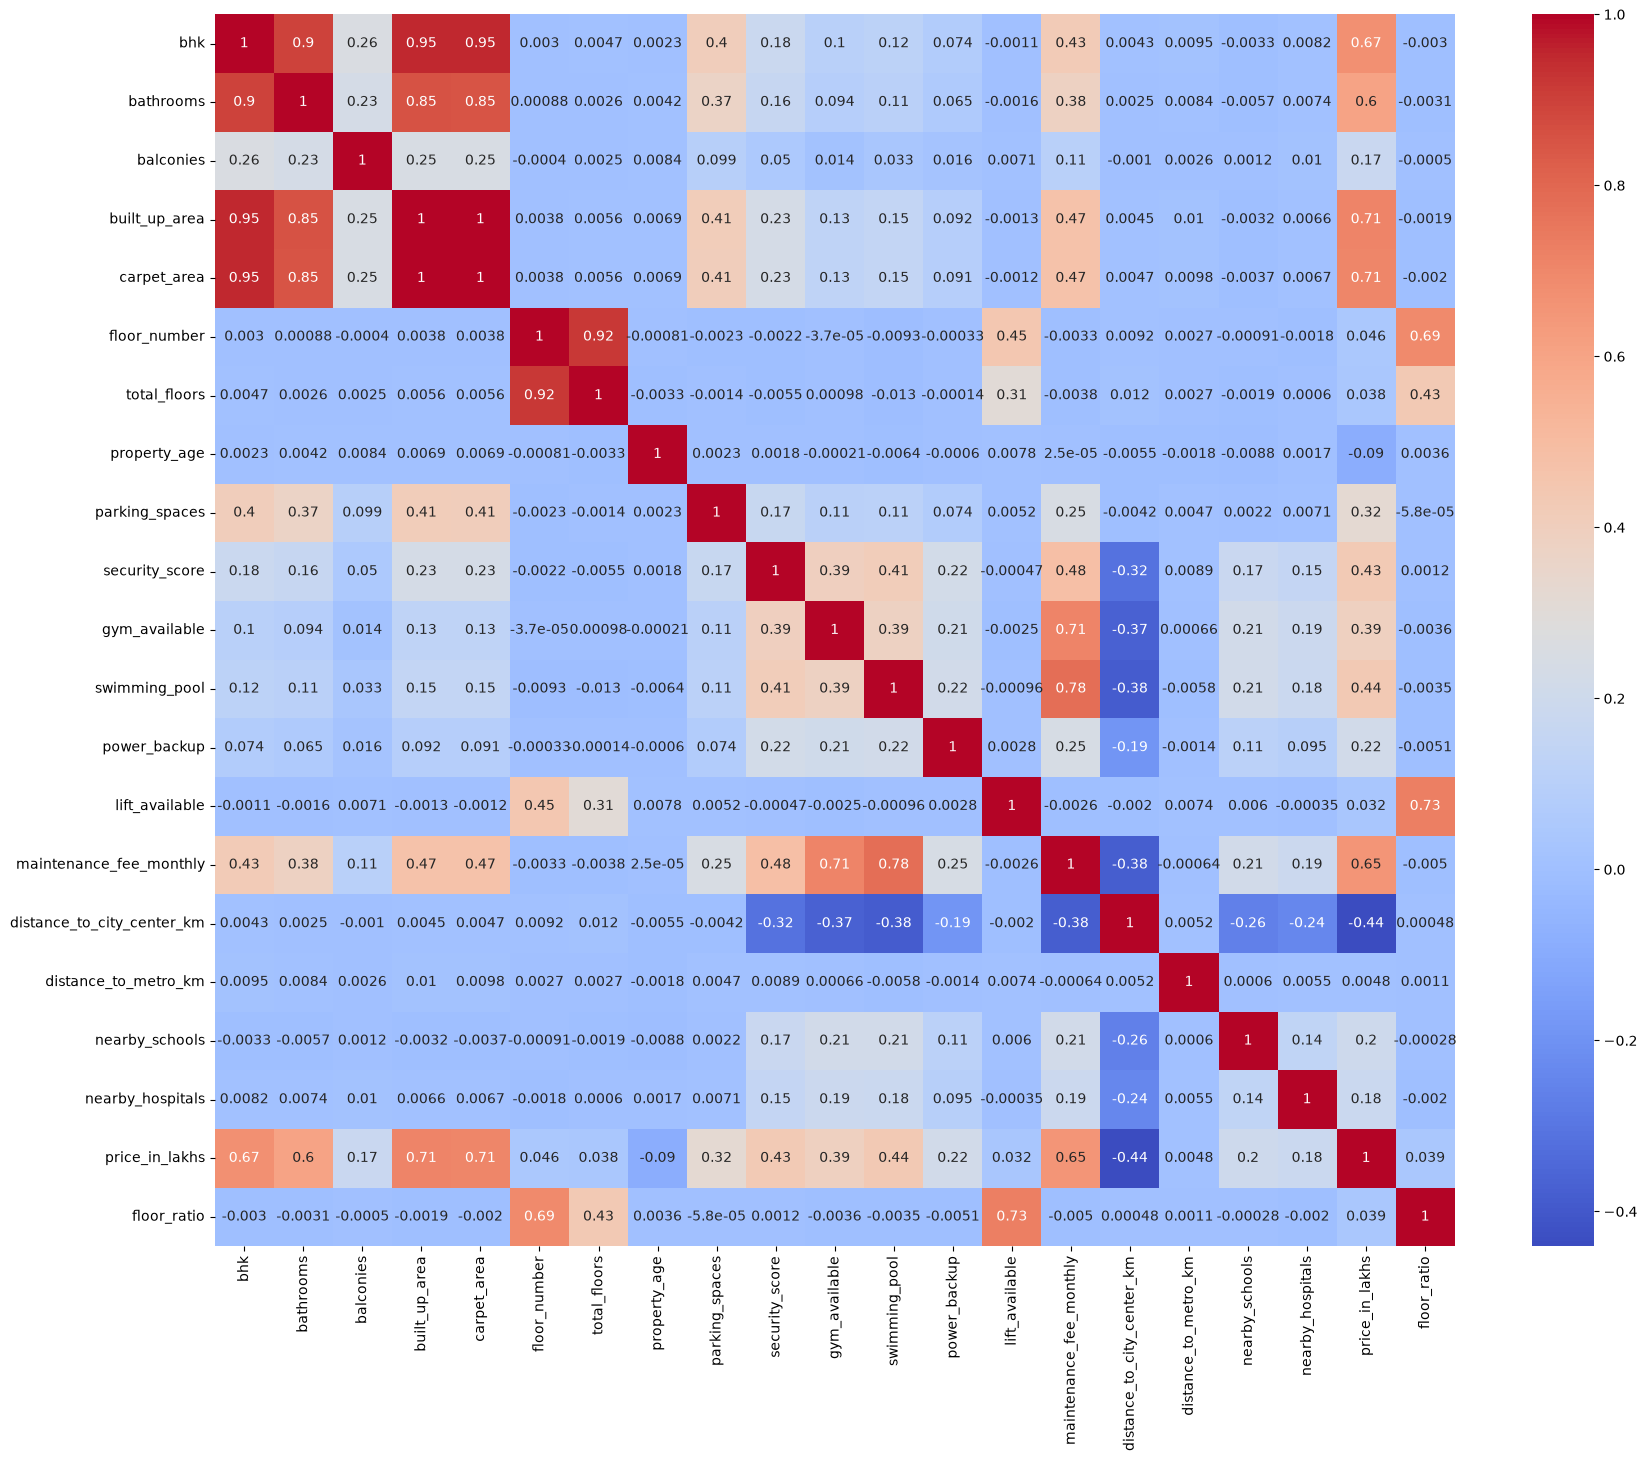

In [16]:
plt.figure(figsize=(20,16))
sns.heatmap(corr_matr, annot=True, cmap='coolwarm')

<Axes: >

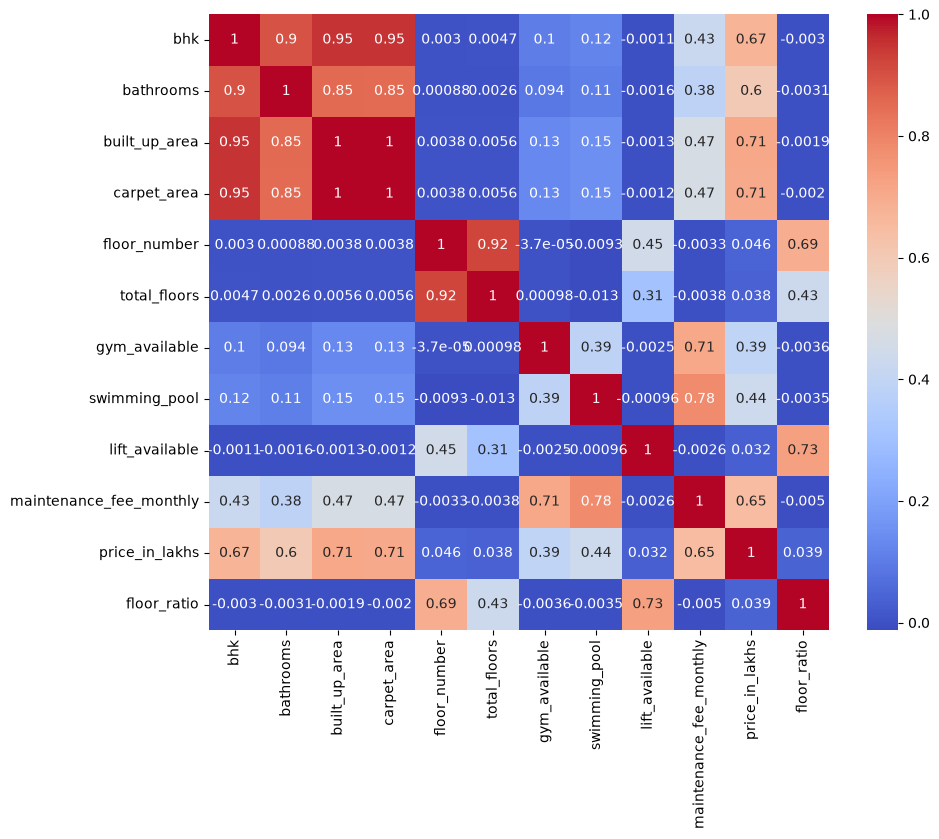

In [17]:
thrsld = 0.7
corr_matr_cond = abs(corr_matr) > 0.7

selezione = []
for i in corr_matr_cond.columns:
    if corr_matr_cond[i].sum() > 1:
        selezione.append(i)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matr[selezione].loc[selezione], annot=True, cmap='coolwarm')

In [18]:
df.head()

,property_id,city,locality,locality_tier,property_type,bhk,bathrooms,balconies,built_up_area,carpet_area,...,maintenance_fee_monthly,distance_to_city_center_km,distance_to_metro_km,nearby_schools,nearby_hospitals,transaction_type,price_in_lakhs,price_category,SOURCE_FILE,floor_ratio
0,PROP-045251,Mumbai,Bandra,Premium,Studio,1,1,0,526,454,...,5388,10.1,8.1,2,5,Resale,69.01,Low,HousingPricePredictionDataset_train.csv,0.000000
1,PROP-037124,Bangalore,Whitefield,Standard,Villa,3,3,1,1833,1563,...,5916,11.2,2.6,2,1,Resale,153.72,Low,HousingPricePredictionDataset_train.csv,0.962963
2,PROP-017296,Mumbai,Powai,Standard,Independent House,3,3,1,1732,1452,...,3166,10.3,2.4,3,2,New,122.76,Low,HousingPricePredictionDataset_train.csv,0.833333
3,PROP-031278,Bangalore,Electronic City,Standard,Studio,1,2,0,447,362,...,1776,10.0,2.4,0,1,Resale,20.80,Low,HousingPricePredictionDataset_train.csv,0.800000
4,PROP-034818,Mumbai,Thane,Affordable,Villa,4,5,0,2276,1944,...,4667,23.5,0.6,3,0,Resale,177.95,Low,HousingPricePredictionDataset_train.csv,0.500000


In [19]:
df['property_id'].isnull().sum()

np.int64(0)

In [20]:
df.isnull().sum()

property_id                   0
city                          0
locality                      0
locality_tier                 0
property_type                 0
bhk                           0
bathrooms                     0
balconies                     0
built_up_area                 0
carpet_area                   0
floor_number                  0
total_floors                  0
floor_category                0
facing                        0
furnishing_status             0
property_age                  0
parking_spaces                0
security_score                0
gym_available                 0
swimming_pool                 0
power_backup                  0
lift_available                0
maintenance_fee_monthly       0
distance_to_city_center_km    0
distance_to_metro_km          0
nearby_schools                0
nearby_hospitals              0
transaction_type              0
price_in_lakhs                0
price_category                0
SOURCE_FILE                   0
floor_ra

In [21]:
df.duplicated(subset = df.columns[1:]).sum()

np.int64(0)

# Linear Correlation with Price

In [22]:
num_cols = list(df.select_dtypes(include=['number']).columns)
num_cols.remove('price_in_lakhs')
num_cols

['bhk',
 'bathrooms',
 'balconies',
 'built_up_area',
 'carpet_area',
 'floor_number',
 'total_floors',
 'property_age',
 'parking_spaces',
 'security_score',
 'gym_available',
 'swimming_pool',
 'power_backup',
 'lift_available',
 'maintenance_fee_monthly',
 'distance_to_city_center_km',
 'distance_to_metro_km',
 'nearby_schools',
 'nearby_hospitals',
 'floor_ratio']

<Axes: xlabel='distance_to_city_center_km', ylabel='price_in_lakhs'>

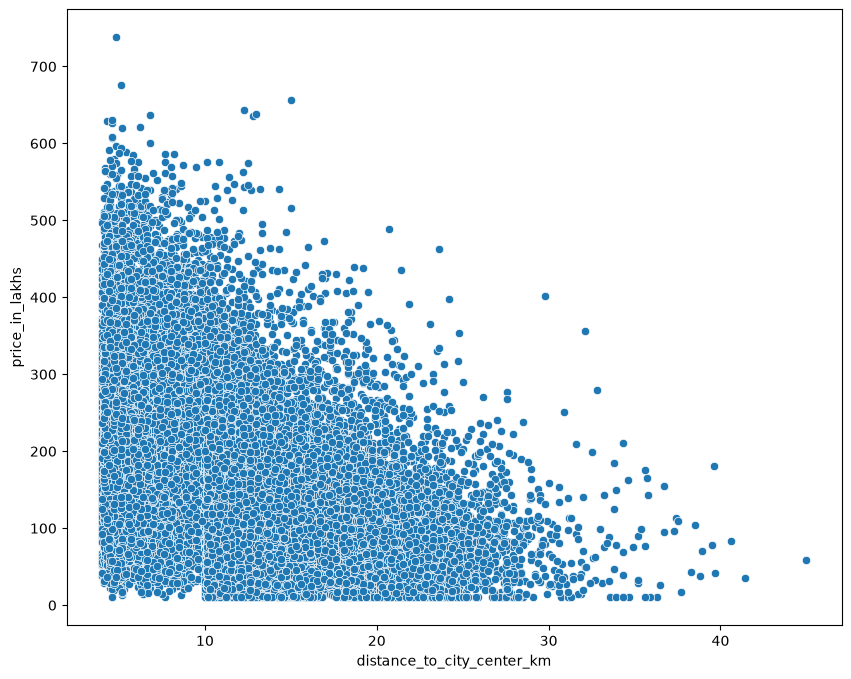

In [23]:
plt.figure(figsize=(10,8))
sns.scatterplot(data = df, x = 'distance_to_city_center_km' , y ='price_in_lakhs')

# Categorical Cols

In [24]:
cat_col = list(df.select_dtypes(exclude=['number']).columns)
cat_col.remove('property_id')
cat_col.remove('price_category')
cat_col.remove('SOURCE_FILE')
cat_col

['city',
 'locality',
 'locality_tier',
 'property_type',
 'floor_category',
 'facing',
 'furnishing_status',
 'transaction_type']

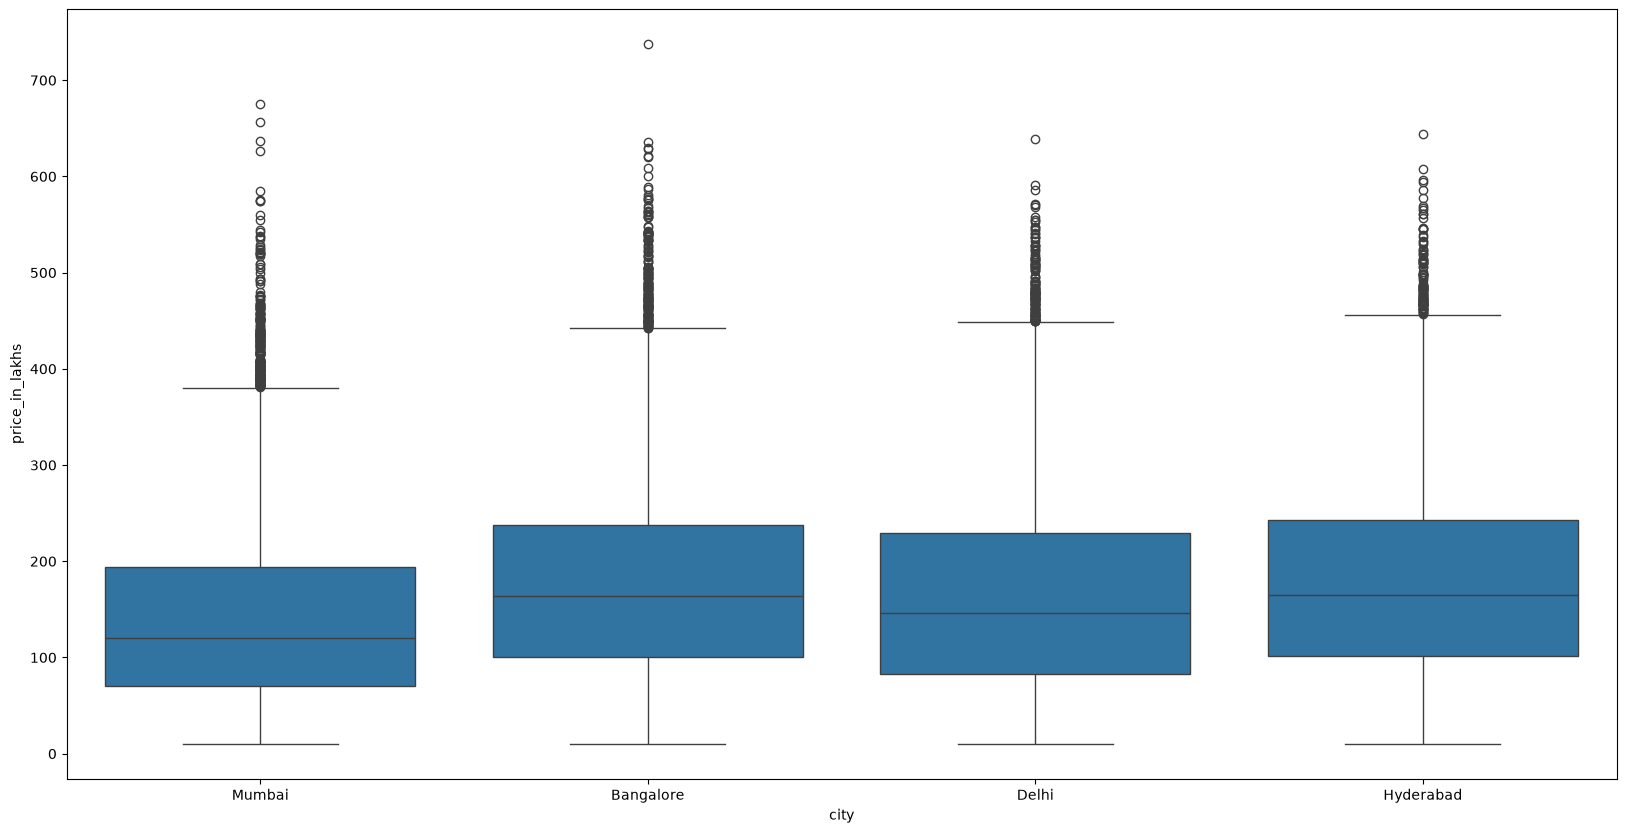

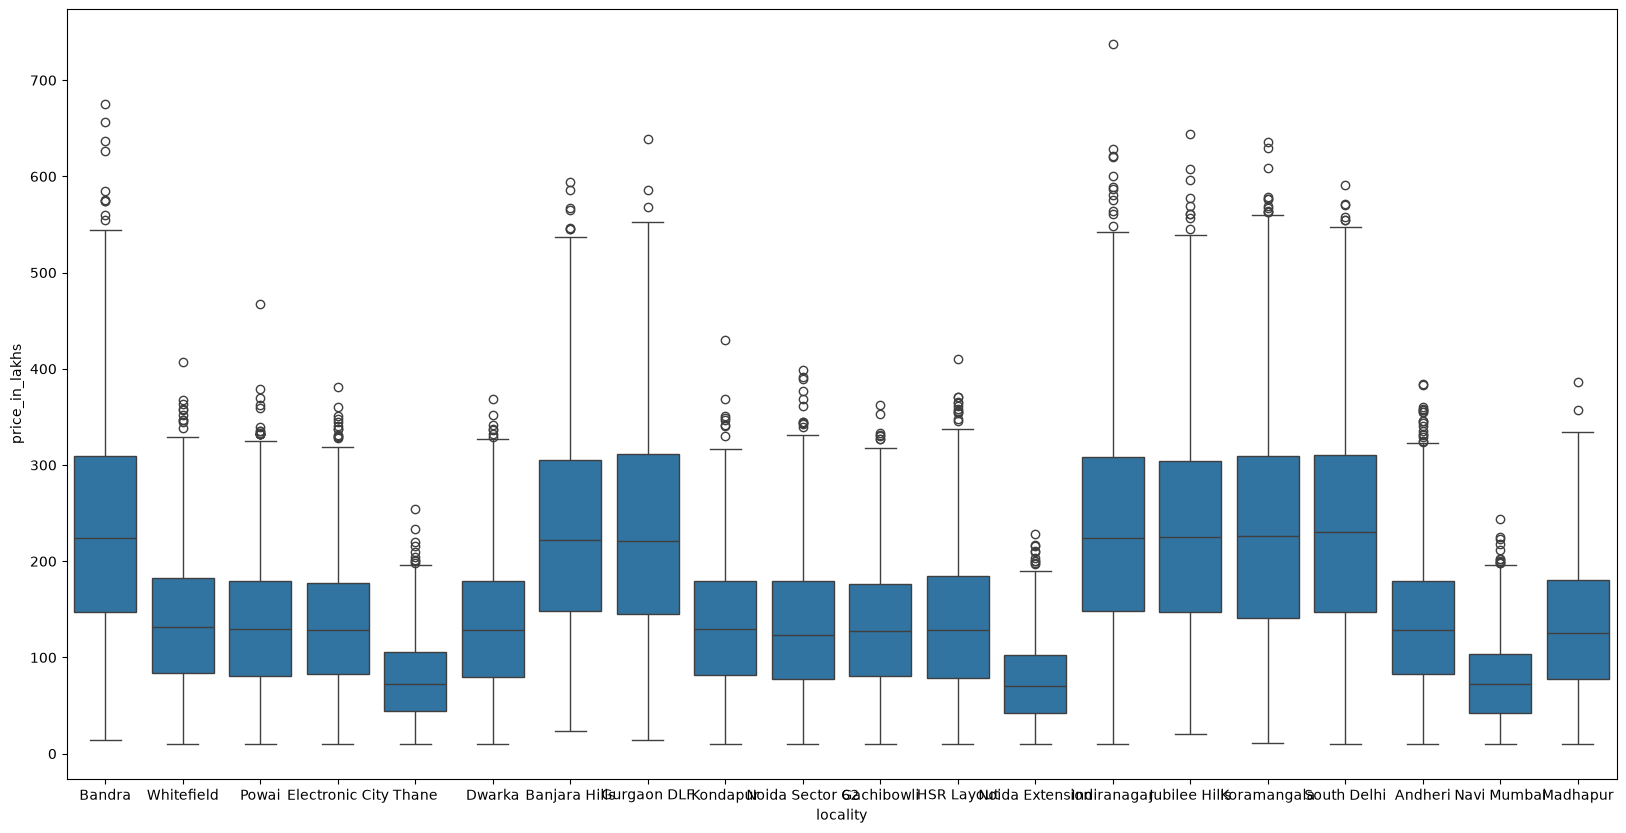

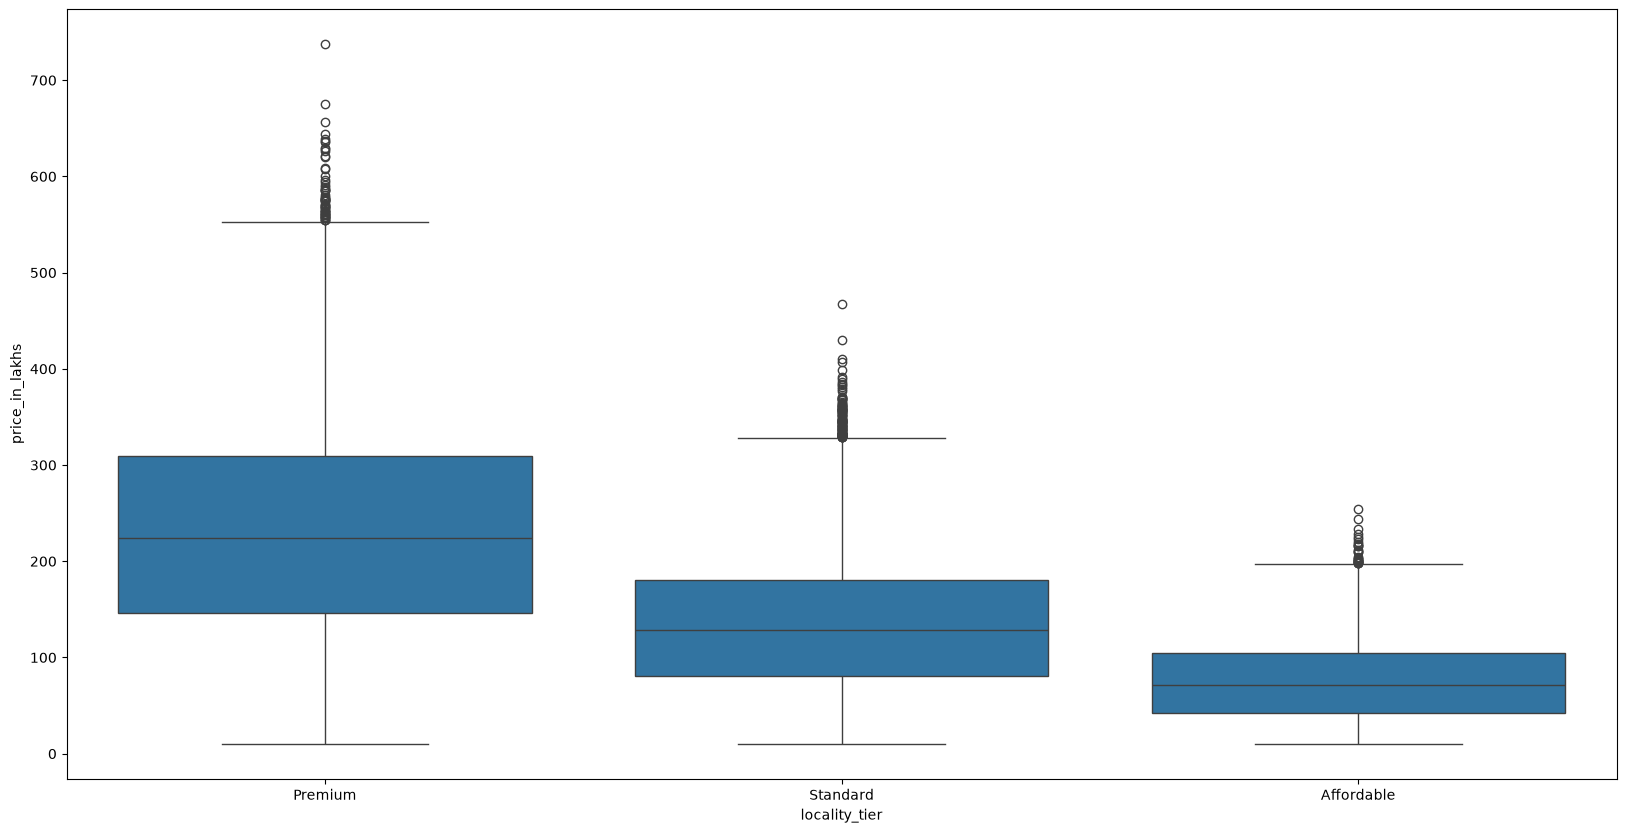

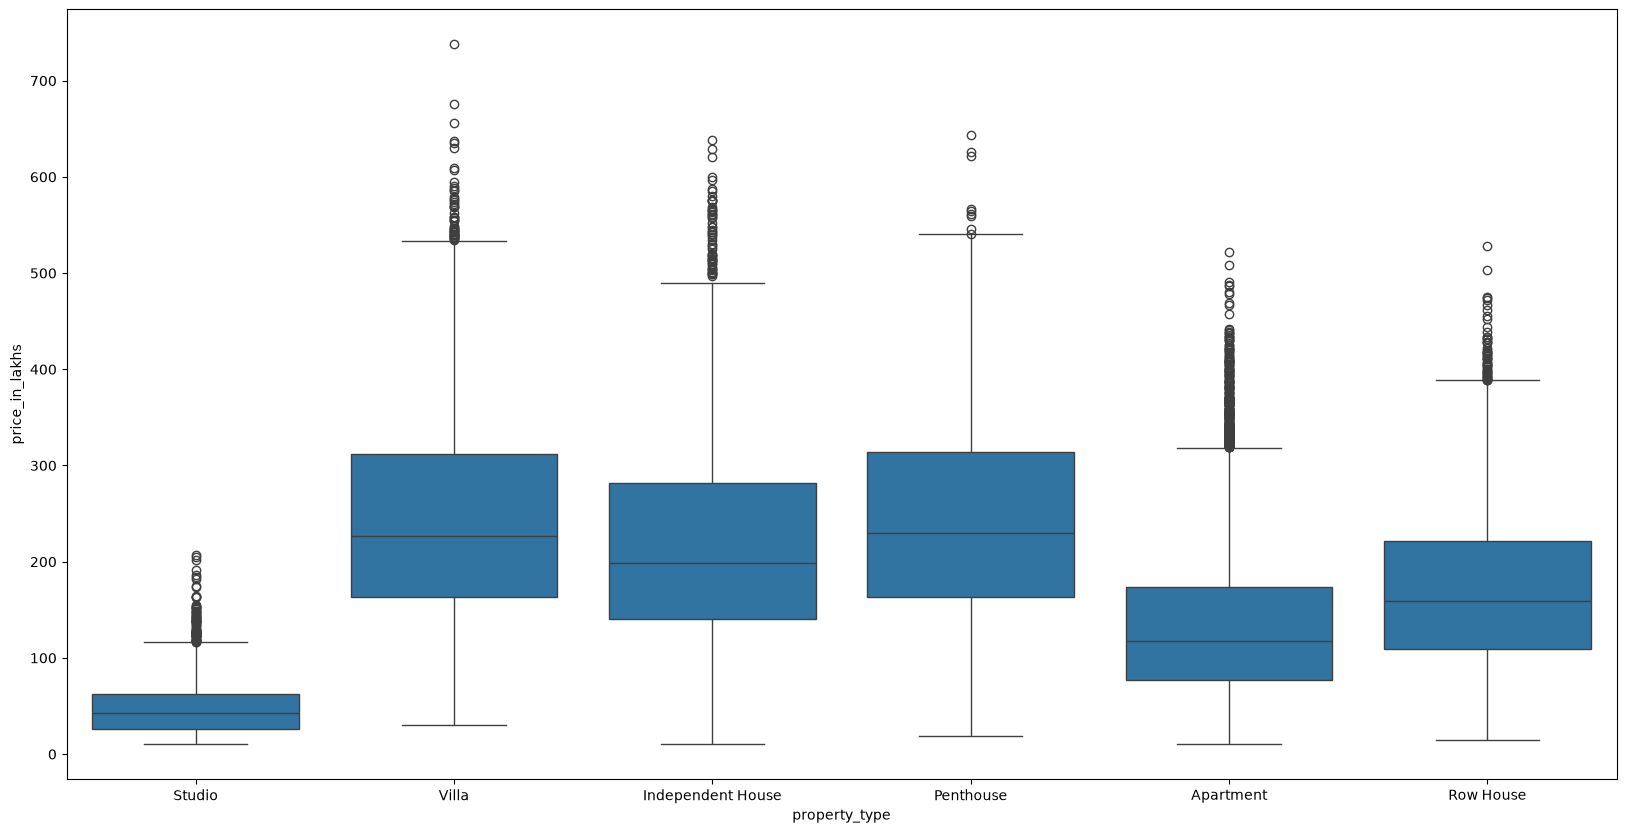

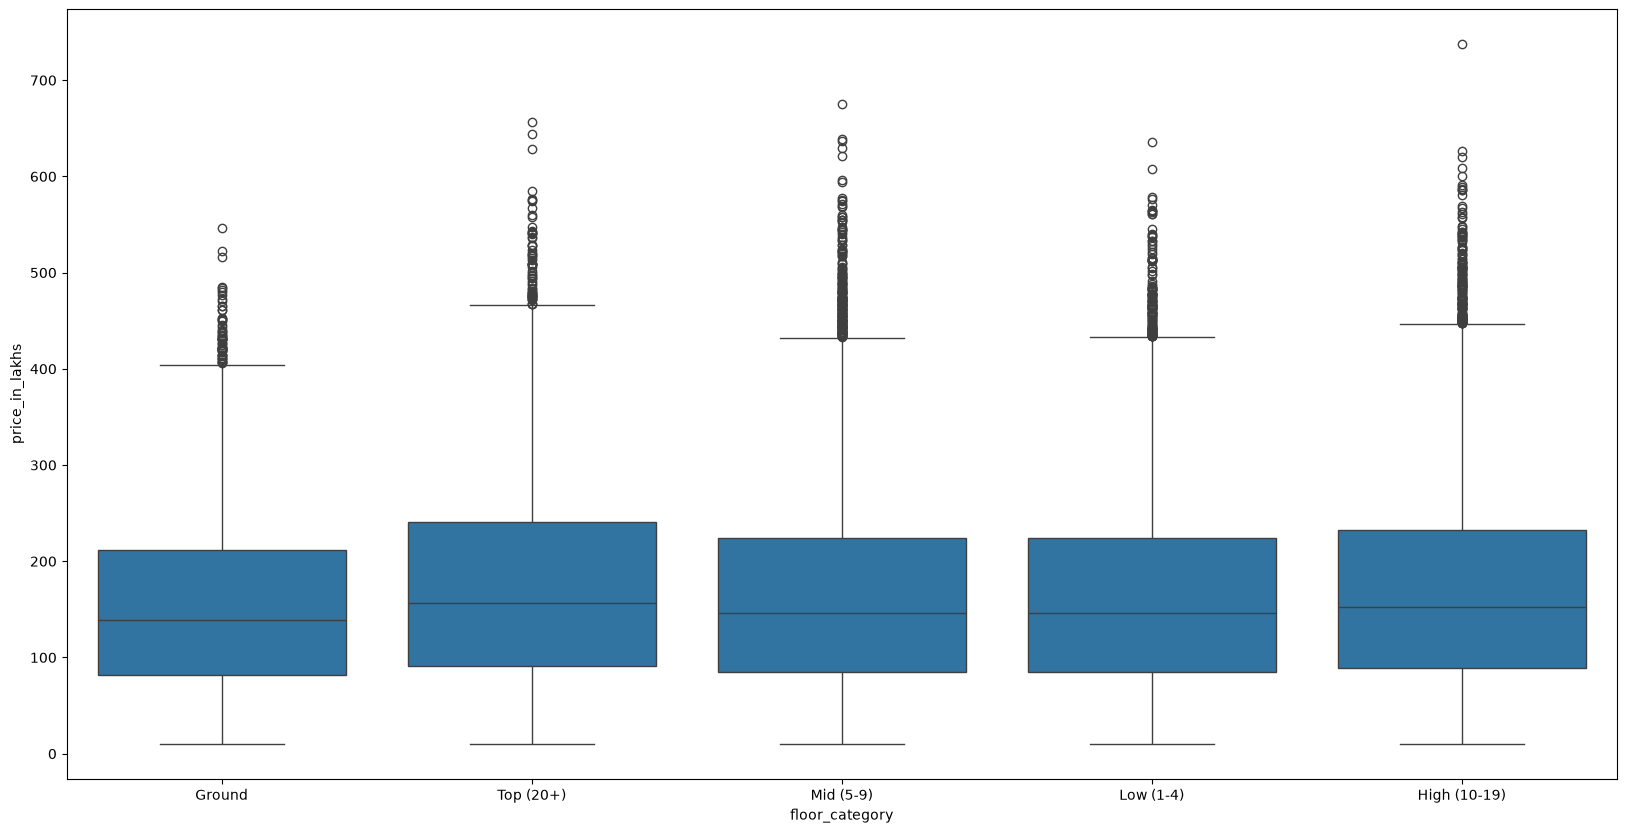

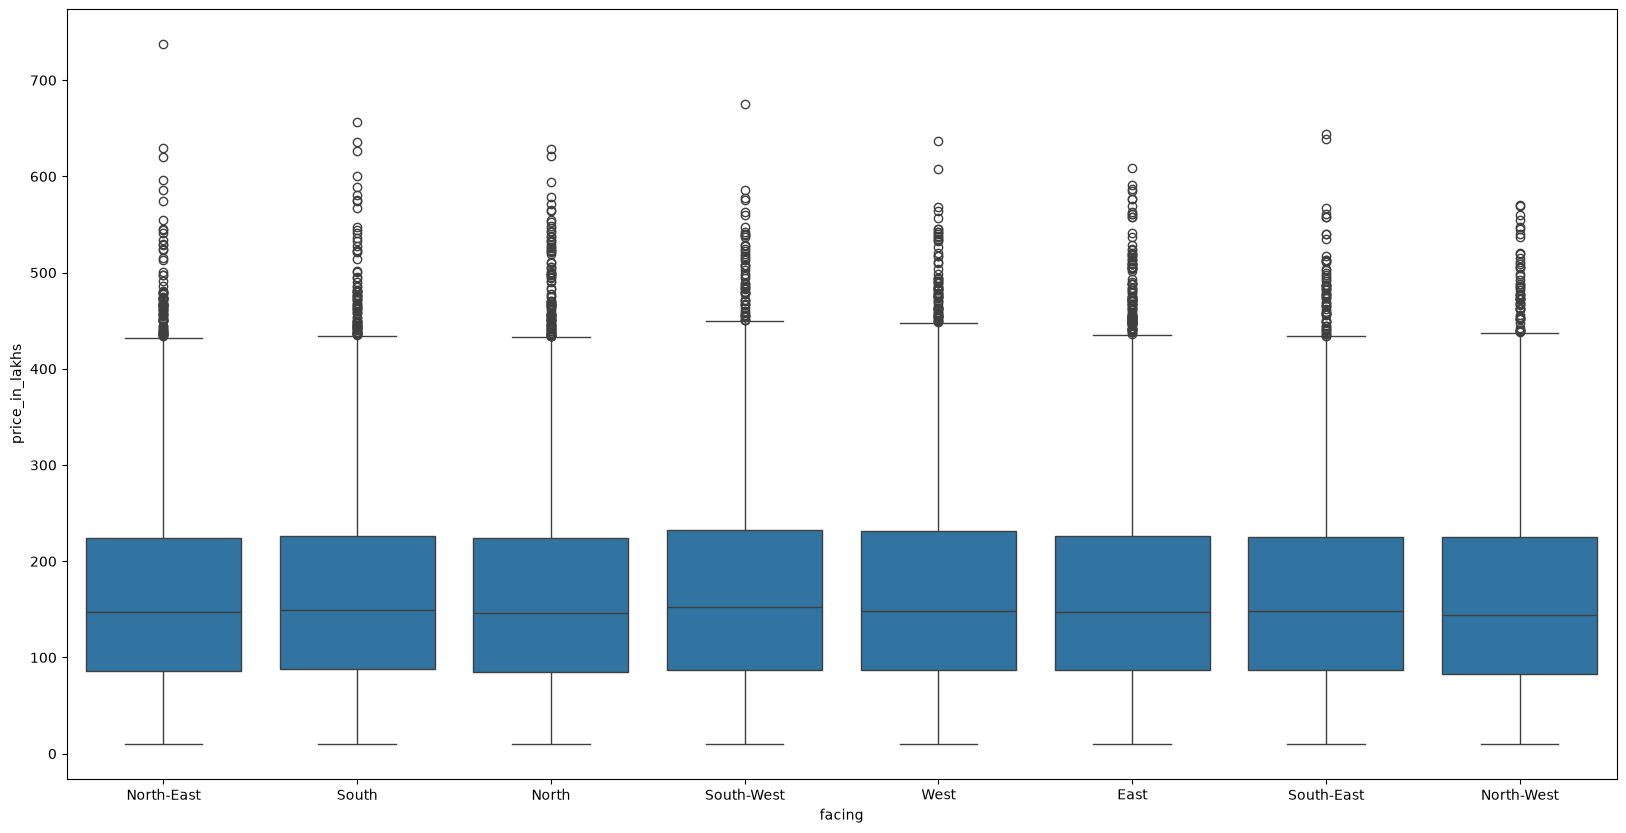

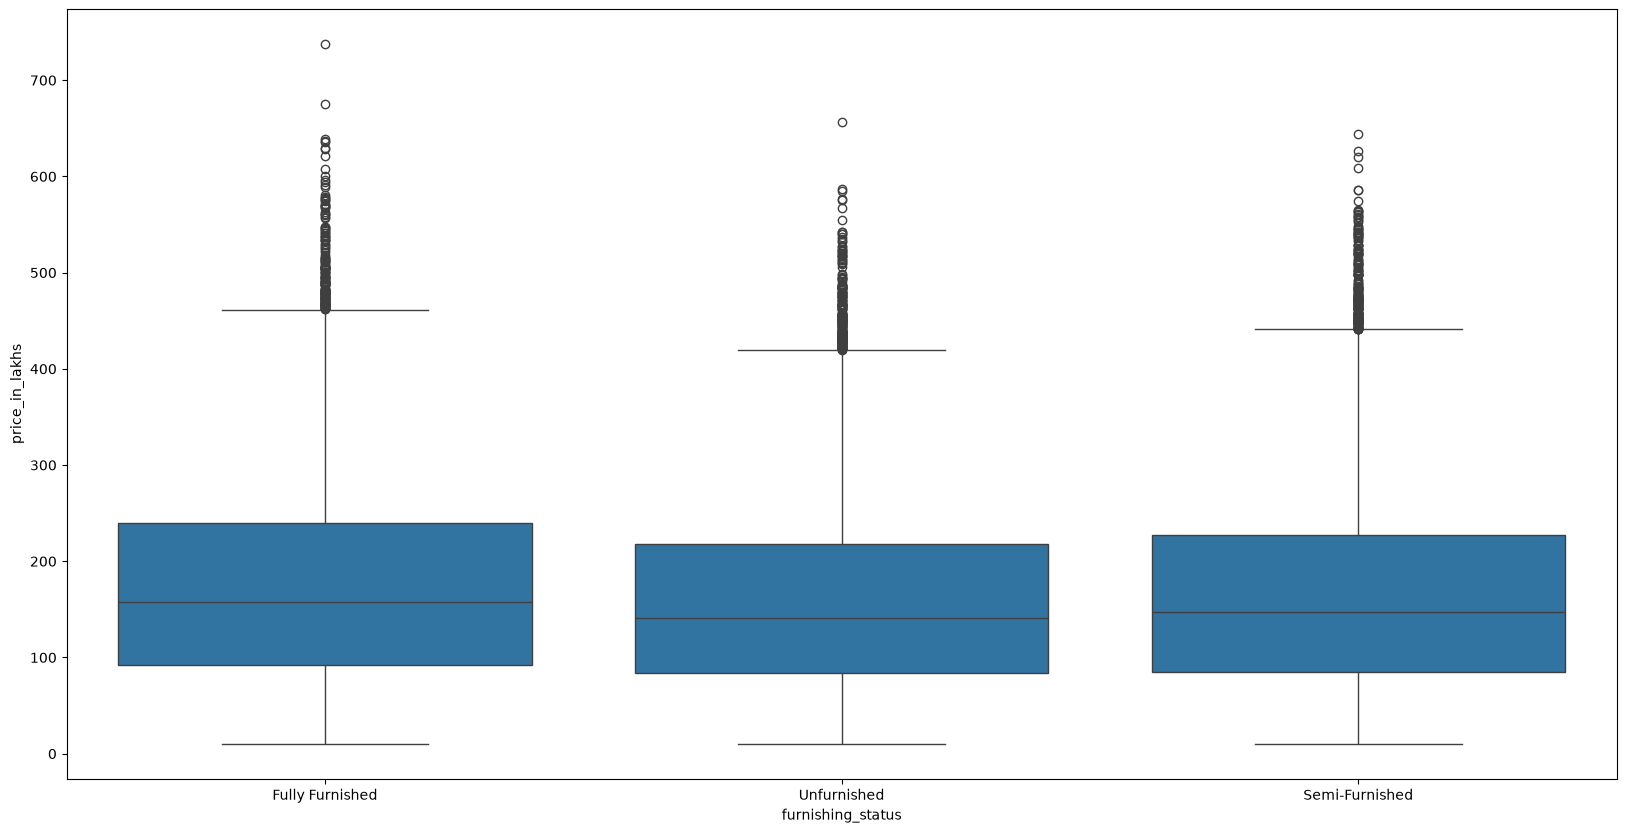

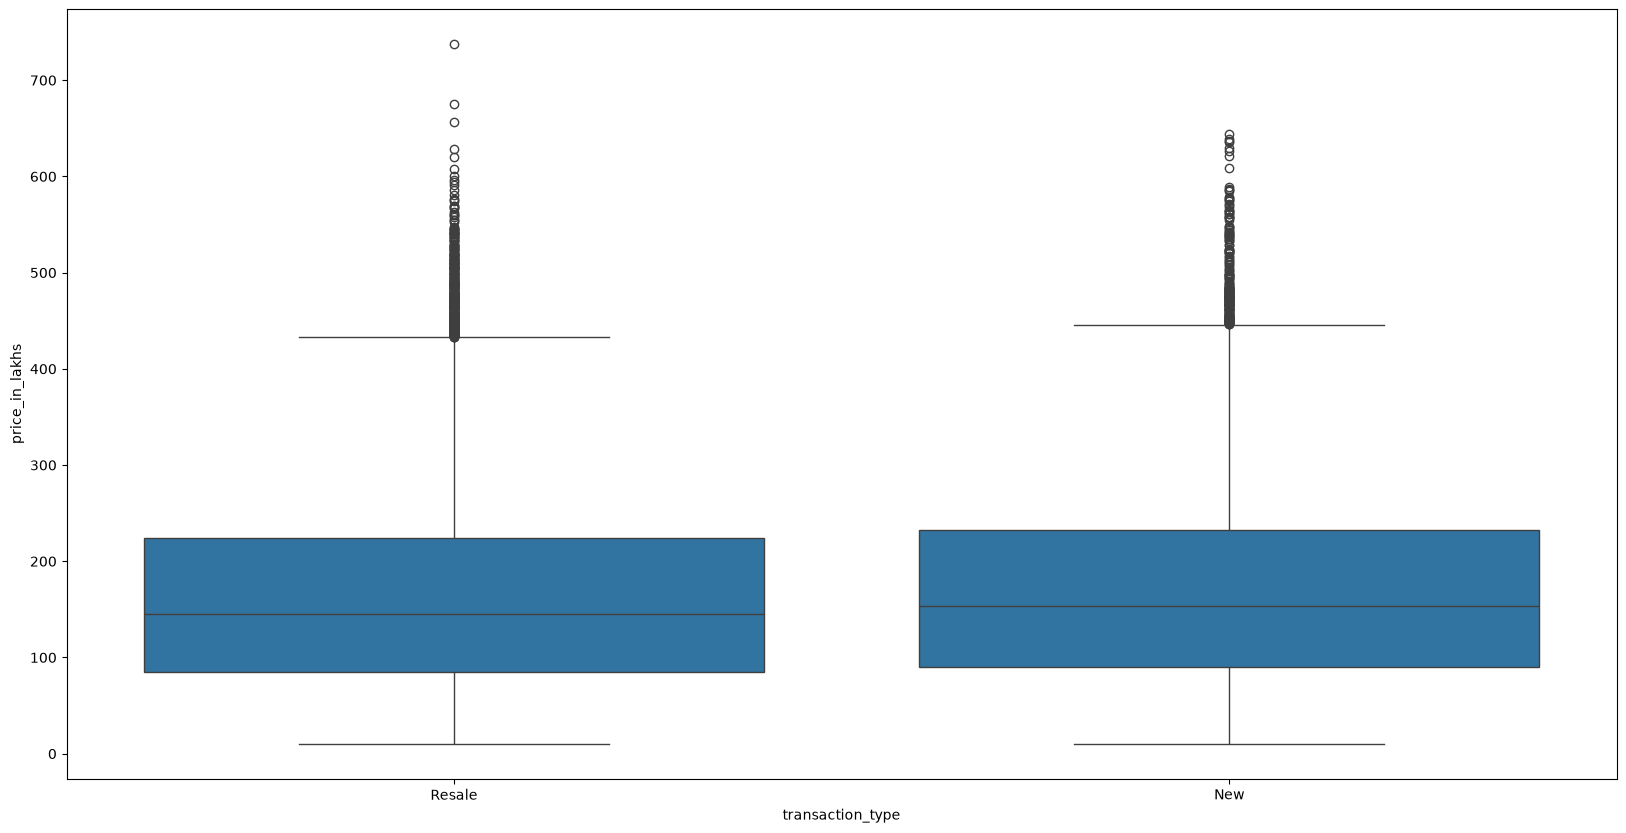

In [25]:
for i in cat_col:
    plt.figure(figsize = (20,10))
    sns.boxplot(x=df[i], y=df['price_in_lakhs'])
    plt.show()

In [26]:
sourcefile_list_raw = df_snowpark.select(col('SOURCE_FILE')).distinct().collect()
sourcefile_list = []

for i in sourcefile_list_raw:
    for j in i:
        sourcefile_list.append(j)


sourcefile_list

['HousingPricePredictionDataset_train.csv']

In [27]:
sourcefile_dqr_list = []
table_exist = False

try:
    dqr_df = session.table("HOUSING_PRICE_PROJECT.STAGING_LAYER.DATA_QUALITY_REPORT")
    sourcefile_dqr_raw = dqr_df.select(col('SOURCE_FILE')).distinct().collect()
    table_exist = True
    
    for i in sourcefile_dqr_raw:
        for j in i:
            sourcefile_dqr_list.append(j)
except:
    pass

print(sourcefile_dqr_list)
print(table_exist)

[]
False


In [ ]:
from itertools import product

tab_name = "TEST_TAB2"


for sc in sourcefile_list:

    if sc in sourcefile_dqr_list:
        continue
    
    
    df_filtered = df_snowpark.filter(
        (col('SOURCE_FILE') == sc)
    )

    schema = ['SOURCE_FILE', 'CHECK_TYPE', 'OTHER']
    line = ["'" + sc + "'"]    
    
    cols = df_filtered.columns
    cols.remove('SOURCE_FILE')

    cols

    # CREATE TAB HEADER (schema) AND ROW WITH MISSING VALUE (line) ****************************************************
    line, schema = null_count(df_filtered, schema, line, cols)
    
    if not table_exist:
        create_tab(session, tab_name, schema)

    inserting(session, tab_name, schema, line)
    

In [ ]:
# CHECK FOR NULL VALUE FUNCTION ****************
def null_count(df_filtered, schema, line, cols):
    
    for col_name in cols: 
        a = df_filtered.select(
            count(when(col(col_name).is_null(), 1)).alias(f"NULL_COUNT")
        ).collect()

        if len(line) == 1:
            line.append("'NULL_COUNT'")
            line.append("NULL")
        
        line.append(str(a[0][0]))
        schema.append(col_name)

    return line, schema

In [ ]:
# CREATE TABLE IF NOT EXISTS *************************************************************************************
def create_tab(session, tab_name, schema):
    col_dtypes = []
        
    for i in schema:
        if i == 'SOURCE_FILE' or i == 'CHECK_TYPE':
            col_dtypes.append(i + " STRING")
        else:
            col_dtypes.append(i + " NUMERIC")
        
    query_create = f"""CREATE TABLE IF NOT EXISTS HOUSING_PRICE_PROJECT.STAGING_LAYER.{tab_name} ({", ".join(col_dtypes)});"""   
    session.sql(query_create).collect()

In [ ]:
# INSERTING ROW WITH MISSING VALUE IF NOT EXISTS *****************************************************************

def inserting(session, tab_name, schema, line):
    
    report_tab = session.table(f"HOUSING_PRICE_PROJECT.STAGING_LAYER.{tab_name}")
    
    query_insert = f"""INSERT INTO HOUSING_PRICE_PROJECT.STAGING_LAYER.{tab_name} 
    ({", ".join(schema)})
    VALUES
    ({", ".join(line)});"""
    
    session.sql(query_insert).collect()

In [ ]:
session.sql("""SELECT * FROM HOUSING_PRICE_PROJECT.STAGING_LAYER.TEST_TAB2""").to_pandas().head()

## cardinality

In [29]:
cat_col = list(df.select_dtypes(exclude=['number']).columns)
cat_col.remove('property_id')
cat_col.remove('price_category')
cat_col.remove('SOURCE_FILE')
cat_col

['city',
 'locality',
 'locality_tier',
 'property_type',
 'floor_category',
 'facing',
 'furnishing_status',
 'transaction_type']

In [35]:
len(cat_col)

8

In [44]:
for i in cat_col:
    print(f"{i}  ->  {df[i].nunique()}")

city  ->  4
locality  ->  20
locality_tier  ->  3
property_type  ->  6
floor_category  ->  5
facing  ->  8
furnishing_status  ->  3
transaction_type  ->  2


In [51]:
df[cat_col[1]].value_counts()

locality
Bandra             2495
Koramangala        2478
Indiranagar        2140
South Delhi        2131
Whitefield         2109
Andheri            2056
Electronic City    1809
Dwarka             1809
Noida Sector 62    1751
Jubilee Hills      1734
Powai              1702
Gurgaon DLF        1684
Banjara Hills      1671
HSR Layout         1657
Thane              1440
Noida Extension    1430
Gachibowli         1402
Navi Mumbai        1395
Kondapur           1371
Madhapur            736
Name: count, dtype: int64